<a href="https://colab.research.google.com/github/mtchlorence/Projects/blob/main/Dela_Piza_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Import the necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.datasets import make_classification

In [ ]:
#read dataset
data=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/breast_cancer.csv")

In [ ]:
#check data
data

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,5,1,1,1,2,1,3,1,1,2
1,5,4,4,5,7,10,3,2,1,2
2,3,1,1,1,2,2,3,1,1,2
3,6,8,8,1,3,4,3,7,1,2
4,4,1,1,3,2,1,3,1,1,2
...,...,...,...,...,...,...,...,...,...,...
678,3,1,1,1,3,2,1,1,1,2
679,2,1,1,1,2,1,1,1,1,2
680,5,10,10,3,7,3,8,10,2,4
681,4,8,6,4,3,4,10,6,1,4


In [ ]:
#mount drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#define features
#Class - (‘malignant’ = 4 or ‘benign’ = 2. )
x=data.drop(['Clump Thickness', 'Uniformity of Cell Size', 'Uniformity of Cell Shape', 'Marginal Adhesion', 'Single Epithelial Cell Size', 'Bare Nuclei', 'Bland Chromatin', 'Normal Nucleoli', 'Mitoses'],axis=1).values
y=data['Class'].values

In [ ]:
#Split the dataset.
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.25, random_state=12, stratify=y)


In [ ]:
#Show the shape of the training set and the test set
print(x_train.shape)
print(x_test.shape)

(512, 1)
(171, 1)


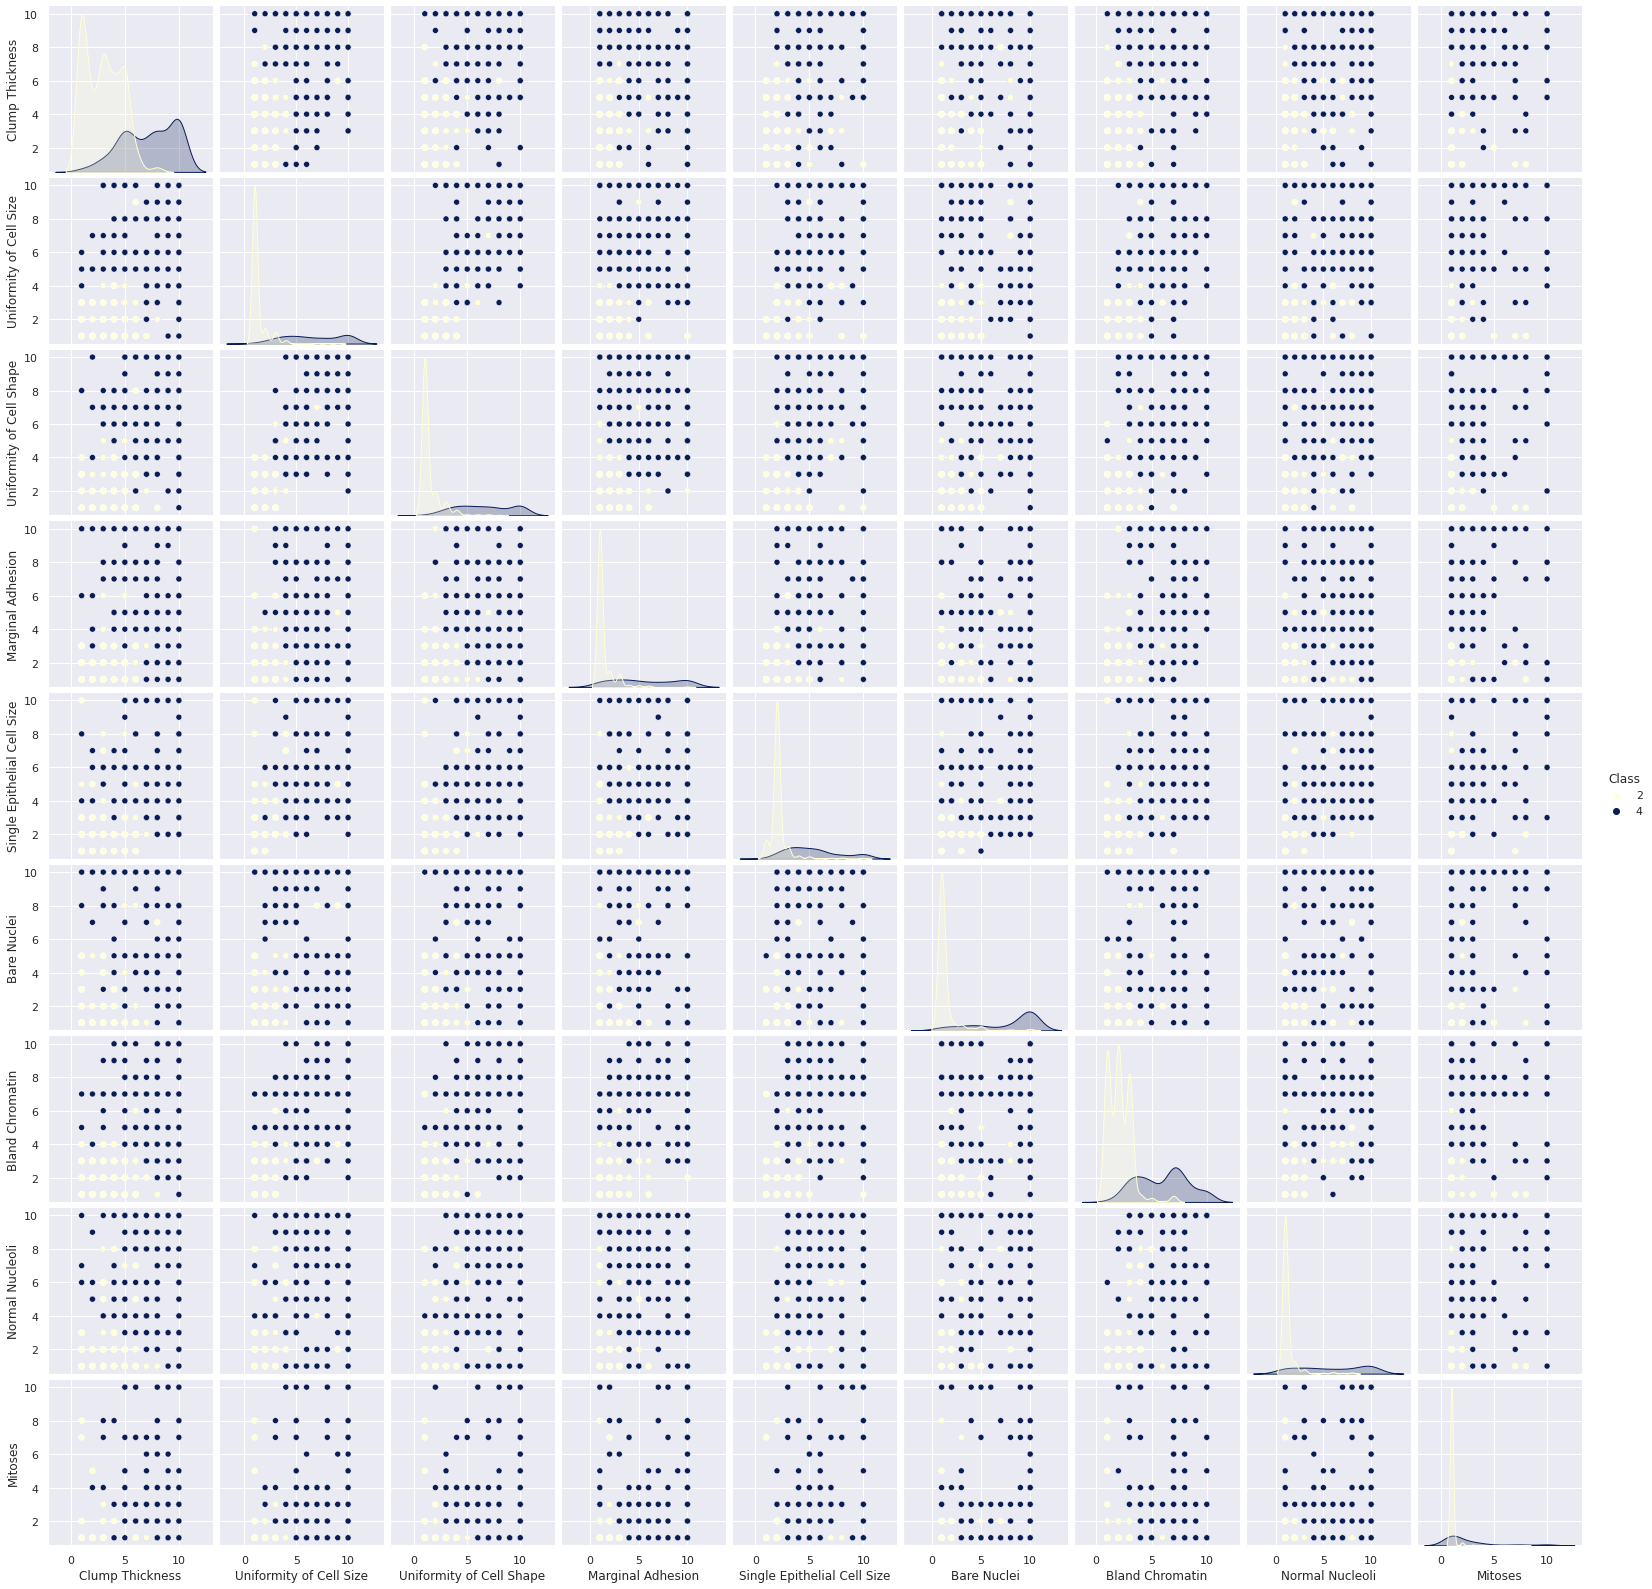

In [ ]:
#create Pairplot
x_vars= ['Clump Thickness', 'Uniformity of Cell Size', 'Uniformity of Cell Shape', 'Marginal Adhesion', 'Single Epithelial Cell Size', 'Bare Nuclei', 'Bland Chromatin', 'Normal Nucleoli', 'Mitoses']
y_var = 'Class'

# Create a pairplot with the outcome variable as hue
sns.pairplot(data, vars=x_vars, hue=y_var, palette='YlGnBu')

# Show the plot
plt.show()

In [ ]:
#Build the model and peroform Logistic Regression
#We build our logistic regression model by fitting on our training data to the model.

logits=LogisticRegression()
logits.fit(x_train, y_train)

LogisticRegression()

In [ ]:
#Show the logits intercept and coefficient
print(logits.intercept_)
print(logits.coef_)

[-14.24863523]
[[4.6450756]]


In [ ]:
#Make predictions using the model.
y_pred=logits.predict(x_test)

In [ ]:
diff=pd.DataFrame({'Actual Value': y_test,'Predicted Value': y_pred})

#Show the Actual Value vs. Predicted Value
diff

,Actual Value,Predicted Value
0,4,4
1,2,2
2,4,4
3,4,4
4,2,2
...,...,...
166,4,4
167,2,2
168,2,2
169,4,4


In [ ]:
#Compute the performance of the model
#One of the measures to compute the performance of the model is accuracy:

print('Accuracy of the logistic regression classifier on test set:{:.2f}%'.format(logits.score(x_test, y_test)*100))

Accuracy of the logistic regression classifier on test set:100.00%


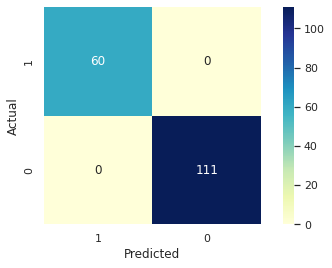

In [ ]:
#Show the confusion matrix and classification report
from sklearn.metrics import confusion_matrix
import seaborn as sns
confusion_matrix=confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,4))
sns.set(font_scale=1)
ax=sns.heatmap(confusion_matrix, cmap='YlGnBu', annot=True, fmt='d', square=True, xticklabels=['0','1'],yticklabels=['0','1'])
ax.set(xlabel='Predicted',ylabel='Actual')
ax.invert_yaxis()
ax.invert_xaxis()

In [ ]:
from sklearn.metrics import classification_report
#y_test=y_test.astype('Category')
print(classification_report(y_test,y_pred))#, labels=y_train.cat.categories.tolist())

              precision    recall  f1-score   support

           2       1.00      1.00      1.00       111
           4       1.00      1.00      1.00        60

    accuracy                           1.00       171
   macro avg       1.00      1.00      1.00       171
weighted avg       1.00      1.00      1.00       171

